<a href="https://colab.research.google.com/github/berrinaydogmus/softito-yapay-zeka/blob/main/MachineLearning_21_09_2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import random
import platform
import sys
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (7, 4)
plt.rcParams["figure.dpi"] = 110

print(f"python: {sys.version.split()[0]}")
print(f"Platform:{platform.platform()}")
print(f"seaborn: {sns.__version__}")
print(f"pandas: {pd.__version__}")
print(f"numpy: {np.__version__}")
print(f"sklearn: {sklearn.__version__}")

python: 3.13.15
Platform:Linux-6.6.122+-x86_64-with-glibc2.39
seaborn: 0.13.2
pandas: 2.2.3
numpy: 2.1.3
sklearn: 1.6.1


In [3]:
#Veri Setini Yükleme
air = pd.read_csv("AirQualityUCI.csv", sep=";", decimal=",")
air = air.loc[:, ~air.columns.str.contains("^Unnamed")]
air = air.dropna(how="all")

air.head(2)

,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
0,10/03/2004,18.00.00,2.6,1360.0,150.0,11.9,1046.0,166.0,1056.0,113.0,1692.0,1268.0,13.6,48.9,0.7578
1,10/03/2004,19.00.00,2.0,1292.0,112.0,9.4,955.0,103.0,1174.0,92.0,1559.0,972.0,13.3,47.7,0.7255


In [5]:
air.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9357 entries, 0 to 9356
Data columns (total 15 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Date           9357 non-null   object 
 1   Time           9357 non-null   object 
 2   CO(GT)         9357 non-null   float64
 3   PT08.S1(CO)    9357 non-null   float64
 4   NMHC(GT)       9357 non-null   float64
 5   C6H6(GT)       9357 non-null   float64
 6   PT08.S2(NMHC)  9357 non-null   float64
 7   NOx(GT)        9357 non-null   float64
 8   PT08.S3(NOx)   9357 non-null   float64
 9   NO2(GT)        9357 non-null   float64
 10  PT08.S4(NO2)   9357 non-null   float64
 11  PT08.S5(O3)    9357 non-null   float64
 12  T              9357 non-null   float64
 13  RH             9357 non-null   float64
 14  AH             9357 non-null   float64
dtypes: float64(13), object(2)
memory usage: 1.1+ MB


In [6]:
#Eksik Değerleri Temizleme
air = air.replace(-200, np.nan)
air = air.drop(columns=["NMHC(GT)"])

print("Eksik değer sayıları:")
print(air.isna().sum())

air = air.dropna().reset_index(drop=True)
print(f"\nTemizlik sonrası satır sayısı: {len(air)}")

Eksik değer sayıları:
Date                0
Time                0
CO(GT)           1683
PT08.S1(CO)       366
C6H6(GT)          366
PT08.S2(NMHC)     366
NOx(GT)          1639
PT08.S3(NOx)      366
NO2(GT)          1642
PT08.S4(NO2)      366
PT08.S5(O3)       366
T                 366
RH                366
AH                366
dtype: int64

Temizlik sonrası satır sayısı: 6941


In [7]:
#Hedef ve Girdi Değişkenleri
X_reg = air.drop(columns=["Date", "Time", "CO(GT)"])
y_reg = air["CO(GT)"]

X_reg.head(2)

,PT08.S1(CO),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
0,1360.0,11.9,1046.0,166.0,1056.0,113.0,1692.0,1268.0,13.6,48.9,0.7578
1,1292.0,9.4,955.0,103.0,1174.0,92.0,1559.0,972.0,13.3,47.7,0.7255


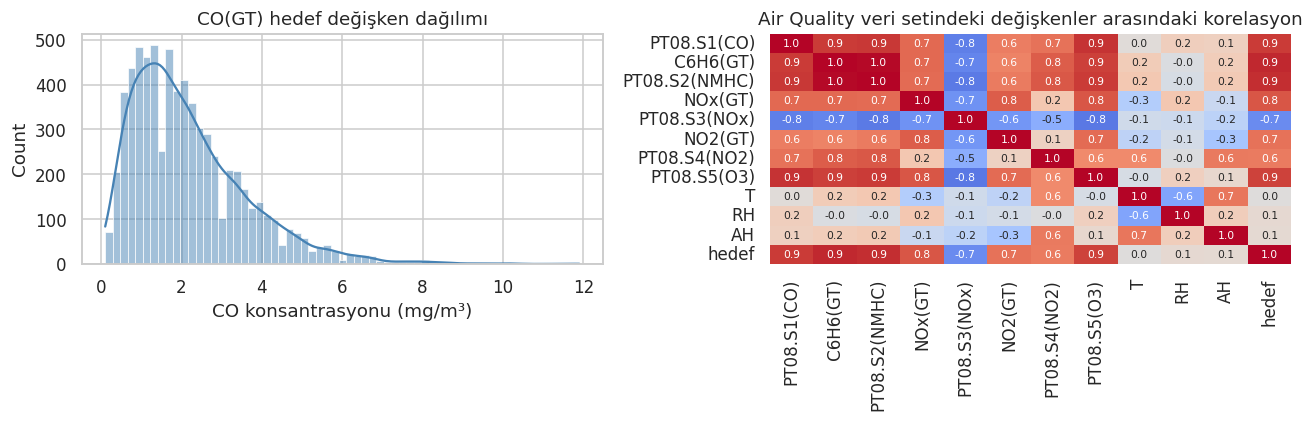

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(y_reg, kde=True, ax=axes[0], color="steelblue")
axes[0].set_title("CO(GT) hedef değişken dağılımı")
axes[0].set_xlabel("CO konsantrasyonu (mg/m³)")

corr = pd.concat([X_reg, y_reg.rename("hedef")], axis=1).corr()
sns.heatmap(corr, annot=True, fmt=".1f", cmap="coolwarm", center=0,
            ax=axes[1], cbar=False, annot_kws={"size": 7})
axes[1].set_title("Air Quality veri setindeki değişkenler arasındaki korelasyon")

plt.tight_layout()
plt.show()

In [9]:
#Eğitim/Test Ayrımı
from sklearn.model_selection import train_test_split
Xr_train, Xr_test, yr_train, yr_test = train_test_split(X_reg, y_reg, test_size=0.2, random_state=SEED)

In [12]:
print(f"{Xr_train.shape[0]}")
Xr_test.shape[0]

5552


1389

In [13]:
#Baseline ve Doğrusal Regresyon
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.dummy import DummyRegressor
baseline = DummyRegressor(strategy="mean").fit(Xr_train, yr_train)

linear = LinearRegression().fit(Xr_train, yr_train)

def regresyon_raporu(model, X, y, ad):
  tahmin = model.predict(X)
  return {
     "Model": ad,
     "Mae": mean_absolute_error(y, tahmin),
     "mse": mean_squared_error(y, tahmin),
     "rmse": np.sqrt(mean_squared_error(y, tahmin)),
     "r2": r2_score(y, tahmin)
    }

sonuc = pd.DataFrame([
    regresyon_raporu(baseline, Xr_test, yr_test, "Baseline"),
    regresyon_raporu(linear, Xr_test, yr_test, "Linear")
]).set_index("Model").round(3)
sonuc

,Mae,mse,rmse,r2
Model,,,,
Baseline,1.058,1.888,1.374,-0.000
Linear,0.258,0.158,0.398,0.916


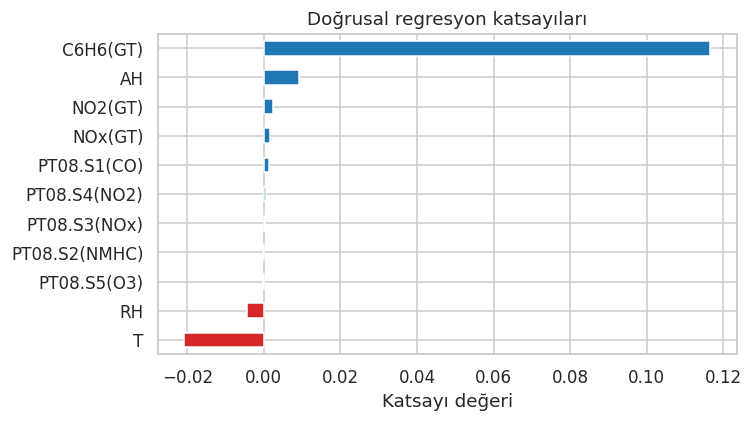

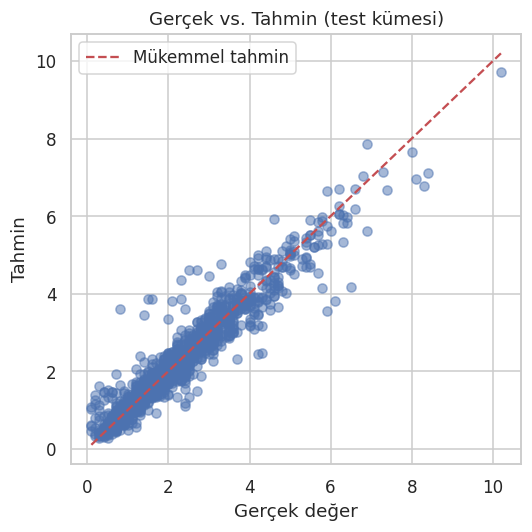

In [14]:
katsayilar = pd.Series(linear.coef_, index=X_reg.columns).sort_values()

plt.figure(figsize=(7, 4))
katsayilar.plot(kind="barh", color=np.where(katsayilar > 0, "tab:blue", "tab:red"))
plt.title("Doğrusal regresyon katsayıları")
plt.xlabel("Katsayı değeri")
plt.tight_layout()
plt.show()

tahmin = linear.predict(Xr_test)
plt.figure(figsize=(5, 5))
plt.scatter(yr_test, tahmin, alpha=0.5)
lim = [yr_test.min(), yr_test.max()]
plt.plot(lim, lim, "r--", label="Mükemmel tahmin")
plt.xlabel("Gerçek değer")
plt.ylabel("Tahmin")
plt.title("Gerçek vs. Tahmin (test kümesi)")
plt.legend()
plt.tight_layout()
plt.show()

In [15]:
#Ridge ve Lasso ile Karşılaştırma
from sklearn.linear_model import Ridge, Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

modeller = {
    "Doğrusal": make_pipeline(StandardScaler(), LinearRegression()),
    "Ridge": make_pipeline(StandardScaler(), Ridge(alpha=1.0)),
    "Lasso": make_pipeline(StandardScaler(), Lasso(alpha=1.0))
}

satirlar = []

for ad, m in modeller.items():
  m.fit(Xr_train, yr_train)
  satirlar.append(regresyon_raporu(m, Xr_test, yr_test, ad))

pd.DataFrame(satirlar).set_index("Model").round(3)

,Mae,mse,rmse,r2
Model,,,,
Doğrusal,0.258,0.158,0.398,0.916
Ridge,0.258,0.158,0.398,0.916
Lasso,0.817,1.131,1.064,0.401


In [16]:
lasso = modeller["Lasso"].named_steps["lasso"]
pd.Series(lasso.coef_, index=X_reg.columns).round(2).to_frame("Lasso değişkenler").T

,PT08.S1(CO),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
Lasso değişkenler,0.0,0.35,0.0,0.0,-0.0,0.0,0.0,0.0,-0.0,0.0,0.0
